In [1]:
# ============================================================
# Cell 1: Imports and setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options so we see useful info, not truncated columns
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Inside Kaggle, the dataset lives at this path
DATA_PATH = Path('/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations')

# If you're running locally, change to wherever you downloaded the files
# DATA_PATH = Path('./data/raw')

In [2]:
# ============================================================
# Cell 2: Load the three core tables
# ============================================================

# IMPORTANT: article_id has leading zeros. Force it to be read as string.
# If you let pandas auto-infer, it'll silently convert "0108775015" to int 108775015,
# and your joins to articles.csv will fail later. This is the #1 newbie bug here.
transactions = pd.read_csv(
    DATA_PATH / 'transactions_train.csv',
    dtype={'article_id': 'str'},
    parse_dates=['t_dat']  # parse the date column as datetime, not string
)

articles = pd.read_csv(
    DATA_PATH / 'articles.csv',
    dtype={'article_id': 'str'}
)

customers = pd.read_csv(DATA_PATH / 'customers.csv')

print(f"Transactions: {transactions.shape}")
print(f"Articles:     {articles.shape}")
print(f"Customers:    {customers.shape}")

Transactions: (31788324, 5)
Articles:     (105542, 25)
Customers:    (1371980, 7)


In [3]:
# ============================================================
# Cell 3: Peek at the data
# ============================================================
print("=== TRANSACTIONS ===")
print(transactions.head())
print(transactions.dtypes)
print()
print(f"Date range: {transactions['t_dat'].min()} to {transactions['t_dat'].max()}")

=== TRANSACTIONS ===
       t_dat                                        customer_id  article_id     price  sales_channel_id
0 2018-09-20  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...  0663713001  0.050831                 2
1 2018-09-20  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...  0541518023  0.030492                 2
2 2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...  0505221004  0.015237                 2
3 2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...  0685687003  0.016932                 2
4 2018-09-20  00007d2de826758b65a93dd24ce629ed66842531df6699...  0685687004  0.016932                 2
t_dat               datetime64[ns]
customer_id                 object
article_id                  object
price                      float64
sales_channel_id             int64
dtype: object

Date range: 2018-09-20 00:00:00 to 2020-09-22 00:00:00


In [4]:
# ============================================================
# Cell 4: Explore the articles (product) table
# ============================================================
print("=== ARTICLES ===")
print(f"Total products: {len(articles):,}")
print(f"Columns: {articles.columns.tolist()}")
print()
print(articles.head(3))

=== ARTICLES ===
Total products: 105,542
Columns: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']

   article_id  product_code      prod_name  product_type_no product_type_name  product_group_name  graphical_appearance_no graphical_appearance_name  colour_group_code colour_group_name  \
0  0108775015        108775      Strap top              253          Vest top  Garment Upper body                  1010016                     Solid                  9             Black   
1  0108775044        108775      Strap top              

In [5]:
# ============================================================
# Cell 5: Catalog composition — what's H&M actually selling?
# ============================================================

# How many items in each high-level group?
print("=== TOP-LEVEL CATEGORY DISTRIBUTION ===")
print(articles['index_group_name'].value_counts())
print()

# How many items per garment group?
print("=== GARMENT GROUPS ===")
print(articles['garment_group_name'].value_counts().head(10))
print()

# Color distribution
print("=== TOP 10 COLORS ===")
print(articles['colour_group_name'].value_counts().head(10))

=== TOP-LEVEL CATEGORY DISTRIBUTION ===
index_group_name
Ladieswear       39737
Baby/Children    34711
Divided          15149
Menswear         12553
Sport             3392
Name: count, dtype: int64

=== GARMENT GROUPS ===
garment_group_name
Jersey Fancy         21445
Accessories          11519
Jersey Basic          8126
Knitwear              7490
Under-, Nightwear     7441
Trousers              6727
Blouses               5838
Shoes                 5145
Dresses Ladies        4874
Outdoor               4501
Name: count, dtype: int64

=== TOP 10 COLORS ===
colour_group_name
Black             22670
Dark Blue         12171
White              9542
Light Pink         5811
Grey               4487
Light Beige        3356
Blue               3308
Red                3056
Light Blue         3012
Greenish Khaki     2767
Name: count, dtype: int64


In [6]:
# ============================================================
# Cell 6: Customer table exploration
# ============================================================
print("=== CUSTOMERS ===")
print(f"Total customers: {len(customers):,}")
print(f"Columns: {customers.columns.tolist()}")
print()
print(customers.head(3))
print()
print("=== AGE DISTRIBUTION ===")
print(customers['age'].describe())
print()
print("=== MISSING VALUES ===")
print(customers.isnull().sum())

=== CUSTOMERS ===
Total customers: 1,371,980
Columns: ['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']

                                         customer_id  FN  Active club_member_status fashion_news_frequency   age                                        postal_code
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3... NaN     NaN             ACTIVE                   NONE  49.0  52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e... NaN     NaN             ACTIVE                   NONE  25.0  2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca... NaN     NaN             ACTIVE                   NONE  24.0  64f17e6a330a85798e4998f62d0930d14db8db1c054af6...

=== AGE DISTRIBUTION ===
count    1.356119e+06
mean     3.638696e+01
std      1.431363e+01
min      1.600000e+01
25%      2.400000e+01
50%      3.200000e+01
75%      4.900000e+01
max    

In [7]:
# ============================================================
# Cell 7: The two most important EDA numbers in any recsys project
# ============================================================

# Number 1: How many transactions per customer?
# This tells us how much history we have to personalize from.
customer_purchase_counts = transactions['customer_id'].value_counts()

print("=== TRANSACTIONS PER CUSTOMER ===")
print(customer_purchase_counts.describe())
print()
print(f"Customers with only 1 purchase: {(customer_purchase_counts == 1).sum():,}")
print(f"Customers with <5 purchases:    {(customer_purchase_counts < 5).sum():,}")
print(f"Customers with >=50 purchases:  {(customer_purchase_counts >= 50).sum():,}")
print()

# Number 2: How concentrated are purchases across items?
# This tells us about the long tail.
article_purchase_counts = transactions['article_id'].value_counts()

print("=== PURCHASES PER ARTICLE ===")
print(article_purchase_counts.describe())
print()
print(f"Top 100 items account for {article_purchase_counts.head(100).sum() / len(transactions) * 100:.1f}% of all purchases")
print(f"Top 1000 items account for {article_purchase_counts.head(1000).sum() / len(transactions) * 100:.1f}% of all purchases")
print(f"Items with only 1 purchase: {(article_purchase_counts == 1).sum():,}")

=== TRANSACTIONS PER CUSTOMER ===
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
Name: count, dtype: float64

Customers with only 1 purchase: 131,514
Customers with <5 purchases:    436,723
Customers with >=50 purchases:  175,792

=== PURCHASES PER ARTICLE ===
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
Name: count, dtype: float64

Top 100 items account for 4.6% of all purchases
Top 1000 items account for 18.2% of all purchases
Items with only 1 purchase: 4,491


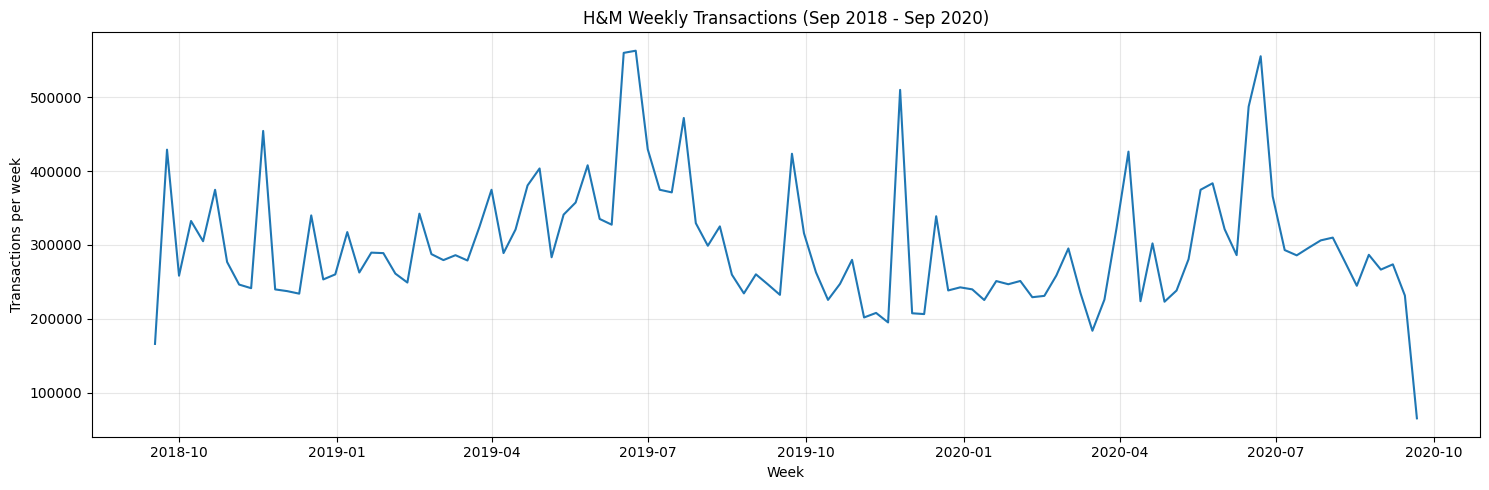


=== RECENT WEEKLY VOLUME ===
          week  transactions
94  2020-07-06        292934
95  2020-07-13        285794
96  2020-07-20        296129
97  2020-07-27        306061
98  2020-08-03        309830
99  2020-08-10        277388
100 2020-08-17        244577
101 2020-08-24        286525
102 2020-08-31        266497
103 2020-09-07        273575
104 2020-09-14        231309
105 2020-09-21         64996


In [8]:
# ============================================================
# Cell 8: Transactions over time — seasonality and trends
# ============================================================
# Aggregate transactions per week
transactions['week'] = transactions['t_dat'].dt.to_period('W').dt.start_time
weekly = transactions.groupby('week').size().reset_index(name='transactions')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(weekly['week'], weekly['transactions'])
ax.set_title('H&M Weekly Transactions (Sep 2018 - Sep 2020)')
ax.set_ylabel('Transactions per week')
ax.set_xlabel('Week')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print recent weeks too
print("\n=== RECENT WEEKLY VOLUME ===")
print(weekly.tail(12))

In [9]:
# ============================================================
# Cell 9: Build a clean temporal train/validation split
# ============================================================

# The competition's test week is the week AFTER the data ends.
# So our validation week should be the LAST week of training data — 
# this perfectly mirrors how the model will be evaluated.

# Find the last date in the data
last_date = transactions['t_dat'].max()
print(f"Last date in data: {last_date}")

# Validation period = last 7 days
validation_start = last_date - pd.Timedelta(days=6)
print(f"Validation period: {validation_start} to {last_date}")

# Split
train_data = transactions[transactions['t_dat'] < validation_start].copy()
valid_data = transactions[transactions['t_dat'] >= validation_start].copy()

print(f"\nTraining transactions:   {len(train_data):,}")
print(f"Validation transactions: {len(valid_data):,}")
print(f"Validation as % of total: {len(valid_data) / len(transactions) * 100:.2f}%")

# Build the ground truth: for each customer, what did they buy in the validation week?
ground_truth = (
    valid_data
    .groupby('customer_id')['article_id']
    .apply(list)  # list of articles each customer bought
    .to_dict()
)

print(f"\nCustomers who bought in validation week: {len(ground_truth):,}")
print(f"(These are the customers we can compute MAP@12 for.)")

# Sanity check — what does the ground truth look like for a few customers?
sample_ids = list(ground_truth.keys())[:3]
for cid in sample_ids:
    print(f"\nCustomer {cid[:12]}... bought {len(ground_truth[cid])} items: {ground_truth[cid][:5]}{'...' if len(ground_truth[cid]) > 5 else ''}")

Last date in data: 2020-09-22 00:00:00
Validation period: 2020-09-16 00:00:00 to 2020-09-22 00:00:00

Training transactions:   31,548,013
Validation transactions: 240,311
Validation as % of total: 0.76%

Customers who bought in validation week: 68,984
(These are the customers we can compute MAP@12 for.)

Customer 00039306476a... bought 1 items: ['0624486001']

Customer 0003e867a930... bought 1 items: ['0827487003']

Customer 000493dd9fc4... bought 3 items: ['0757926001', '0788575004', '0640021019']


In [10]:
list(ground_truth.items())[:10]

[('00039306476aaf41a07fed942884f16b30abfa83a2a8bea972019098d6406793',
  ['0624486001']),
 ('0003e867a930d0d6842f923d6ba7c9b77aba33fe2a0fbf4672f30b3e622fec55',
  ['0827487003']),
 ('000493dd9fc463df1acc2081450c9e75ef8e87d5dd17ed6396773839f6bf71a9',
  ['0757926001', '0788575004', '0640021019']),
 ('000525e3fe01600d717da8423643a8303390a055c578ed8a97256600baf54565',
  ['0874110016']),
 ('00077dbd5c4a4991e092e63893ccf29294a9d5c46e85010e95f2fc10bf9437a4',
  ['0903762001',
   '0879189005',
   '0158340001',
   '0867966009',
   '0915529003',
   '0932798002',
   '0915529005',
   '0486639003',
   '0918171001',
   '0936622001',
   '0907149001',
   '0935892001',
   '0448509014',
   '0799365027']),
 ('0008daf19b2a7cd6fa00836c717aa0f143c83d88c35e0269a28cbff53664205a',
  ['0786304008']),
 ('000fb6e772c5d0023892065e659963da90b1866035558ec16fca51b0dcfb7e59',
  ['0786022008',
   '0913272003',
   '0889669006',
   '0913272003',
   '0889669006',
   '0871519008',
   '0871519008',
   '0871519008',
   '0919273

In [11]:
# ============================================================
# Cell 10: Global Top-12 Popularity baseline
# ============================================================

# Step 1: Define the popularity window — last 7 days of training data
popularity_window_start = validation_start - pd.Timedelta(days=7)
popularity_window_end = validation_start - pd.Timedelta(days=1)
print(f"Popularity computed from: {popularity_window_start} to {popularity_window_end}")

# Step 2: Find the top 12 most-purchased items in that window
recent_train = train_data[
    (train_data['t_dat'] >= popularity_window_start) &
    (train_data['t_dat'] <= popularity_window_end)
]
print(f"Transactions in popularity window: {len(recent_train):,}")

top_12_popular = (
    recent_train['article_id']
    .value_counts()
    .head(12)
    .index
    .tolist()
)

print(f"\nTop 12 popular items in last week of training:")
for rank, item in enumerate(top_12_popular, 1):
    count = recent_train['article_id'].value_counts().loc[item]
    print(f"  {rank:2d}. {item}  ({count:,} purchases)")

Popularity computed from: 2020-09-09 00:00:00 to 2020-09-15 00:00:00
Transactions in popularity window: 255,241

Top 12 popular items in last week of training:
   1. 0909370001  (1,283 purchases)
   2. 0865799006  (768 purchases)
   3. 0918522001  (729 purchases)
   4. 0924243001  (704 purchases)
   5. 0448509014  (609 purchases)
   6. 0751471001  (607 purchases)
   7. 0809238001  (563 purchases)
   8. 0918292001  (546 purchases)
   9. 0762846027  (539 purchases)
  10. 0809238005  (503 purchases)
  11. 0673677002  (463 purchases)
  12. 0923758001  (457 purchases)


In [12]:
# Step 3: Score this recommendation list against the ground truth
# We give EVERY customer the SAME 12 items. The metric will measure
# how often those generic recommendations happen to match what they bought.

def average_precision_at_k(recommended: list, relevant: set, k: int = 12) -> float:
    """
    Compute Average Precision @ K for one user.
    
    recommended: ordered list of recommended item IDs
    relevant:    set of item IDs the user actually bought (ground truth)
    k:           cutoff (12 for this competition)
    """
    if not relevant:
        return 0.0
    
    hits = 0
    sum_precisions = 0.0
    
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            precision_at_i = hits / (i + 1)
            sum_precisions += precision_at_i
    
    # Divide by min(k, |relevant|) — competition convention
    # If user has more than k relevant items, we can only find k of them
    return sum_precisions / min(len(relevant), k)


# Compute AP for each customer with ground truth, using the same top-12 list
ap_scores = []
for customer_id, bought_items in ground_truth.items():
    relevant_set = set(bought_items)
    ap = average_precision_at_k(top_12_popular, relevant_set, k=12)
    ap_scores.append(ap)

map_at_12 = np.mean(ap_scores)
print(f"\n=== BASELINE RESULTS ===")
print(f"Global Top-12 Popularity MAP@12: {map_at_12:.6f}")
print(f"Customers evaluated: {len(ap_scores):,}")
print(f"Customers who got at least 1 hit: {sum(1 for a in ap_scores if a > 0):,}")
print(f"Hit rate (any hit in top 12): {sum(1 for a in ap_scores if a > 0) / len(ap_scores) * 100:.2f}%")


=== BASELINE RESULTS ===
Global Top-12 Popularity MAP@12: 0.008748
Customers evaluated: 68,984
Customers who got at least 1 hit: 4,436
Hit rate (any hit in top 12): 6.43%


In [13]:
# What are these top items, actually?
print("\n=== TOP 12 ARTICLES IN DETAIL ===")
top_12_details = articles[articles['article_id'].isin(top_12_popular)][
    ['article_id', 'prod_name', 'product_type_name', 'colour_group_name', 'index_group_name']
]
# Preserve popularity ordering
top_12_details = top_12_details.set_index('article_id').reindex(top_12_popular).reset_index()
print(top_12_details.to_string(index=False))


=== TOP 12 ARTICLES IN DETAIL ===
article_id                 prod_name product_type_name colour_group_name index_group_name
0909370001         FF PI Haley dress             Dress         Off White       Ladieswear
0865799006            Pink HW barrel          Trousers       Light Beige       Ladieswear
0918522001         Jackie cable vest           Sweater         Off White       Ladieswear
0924243001                   Ohlsson           Sweater             Beige       Ladieswear
0448509014 Perrie Slim Mom Denim TRS          Trousers              Blue          Divided
0751471001       Pluto RW slacks (1)          Trousers             Black       Ladieswear
0809238001       Atomic Wrap Sweater           Sweater             Black          Divided
0918292001 STRONG HW seamless tights   Leggings/Tights             Black            Sport
0762846027               Lucy blouse             Shirt             Beige       Ladieswear
0809238005       Atomic Wrap Sweater           Sweater         Da

In [14]:
# ============================================================
# Cell 11: Segmented popularity by customer's preferred index_group
# ============================================================

# Join transactions with article metadata so we know each transaction's index_group
train_with_meta = train_data.merge(
    articles[['article_id', 'index_group_name']],
    on='article_id',
    how='left'
)

print(f"Training transactions with index_group attached: {len(train_with_meta):,}")
print(f"Distribution of training purchases by index_group:")
print(train_with_meta['index_group_name'].value_counts())

Training transactions with index_group attached: 31,548,013
Distribution of training purchases by index_group:
index_group_name
Ladieswear       20264825
Divided           7079953
Menswear          1757446
Sport             1233236
Baby/Children     1212553
Name: count, dtype: int64


In [15]:
train_with_meta.head()

,t_dat,customer_id,article_id,price,sales_channel_id,week,index_group_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2,2018-09-17,Ladieswear
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2,2018-09-17,Ladieswear
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2,2018-09-17,Divided
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2,2018-09-17,Ladieswear
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2,2018-09-17,Ladieswear


In [16]:
# For each customer, find their most-purchased index_group
# This is fast because we group on customer_id and use mode

customer_segments = (
    train_with_meta
    .groupby('customer_id')['index_group_name']
    .agg(lambda x: x.value_counts().index[0])  # mode = most common value
    .to_dict()
)

print(f"\nCustomers with assigned segment: {len(customer_segments):,}")
print(f"Segment distribution across customers:")
segment_counts = pd.Series(list(customer_segments.values())).value_counts()
print(segment_counts)


Customers with assigned segment: 1,356,709
Segment distribution across customers:
Ladieswear       990960
Divided          221189
Menswear          57200
Baby/Children     55426
Sport             31934
Name: count, dtype: int64


In [17]:
# Attach index_group to the recent (popularity-window) transactions too
recent_train_with_meta = recent_train.merge(
    articles[['article_id', 'index_group_name']],
    on='article_id',
    how='left'
)

# For each segment, compute the top-12 most-purchased items
segment_top_12 = {}
for segment in recent_train_with_meta['index_group_name'].unique():
    if pd.isna(segment):
        continue
    seg_items = (
        recent_train_with_meta[recent_train_with_meta['index_group_name'] == segment]
        ['article_id'].value_counts().head(12).index.tolist()
    )
    segment_top_12[segment] = seg_items

print("\n=== TOP-12 PER SEGMENT (first 3 items shown) ===")
for segment, items in segment_top_12.items():
    print(f"  {segment:25s} → {items[:3]}...")


=== TOP-12 PER SEGMENT (first 3 items shown) ===
  Divided                   → ['0448509014', '0809238001', '0809238005']...
  Ladieswear                → ['0909370001', '0865799006', '0918522001']...
  Menswear                  → ['0685814003', '0685814001', '0685813001']...
  Baby/Children             → ['0885919006', '0866482006', '0885919011']...
  Sport                     → ['0918292001', '0852584001', '0905957001']...


In [18]:
# For each customer in ground_truth, look up their segment and use that segment's top-12
# If we don't know their segment, fall back to global Top-12

fallback_top_12 = top_12_popular  # from Cell 10

ap_scores = []
for customer_id, bought_items in ground_truth.items():
    # Look up this customer's segment, fall back to global if unknown
    segment = customer_segments.get(customer_id)
    if segment is None or segment not in segment_top_12:
        recommendations = fallback_top_12
    else:
        recommendations = segment_top_12[segment]
    
    ap = average_precision_at_k(recommendations, set(bought_items), k=12)
    ap_scores.append(ap)

map_at_12_segmented = np.mean(ap_scores)
hit_rate = sum(1 for a in ap_scores if a > 0) / len(ap_scores) * 100

print(f"\n=== SEGMENTED POPULARITY RESULTS ===")
print(f"Segmented MAP@12: {map_at_12_segmented:.6f}")
print(f"Global   MAP@12: {0.008748:.6f}  (baseline from Cell 10)")
print(f"Lift over global baseline: {(map_at_12_segmented / 0.008748 - 1) * 100:+.1f}%")
print(f"Hit rate: {hit_rate:.2f}%")


=== SEGMENTED POPULARITY RESULTS ===
Segmented MAP@12: 0.009349
Global   MAP@12: 0.008748  (baseline from Cell 10)
Lift over global baseline: +6.9%
Hit rate: 6.92%


In [19]:
# ============================================================
# Cell 12: Age × Index_Group Segmented Popularity
# ============================================================

# Build a customer_id → age_bucket lookup
def assign_age_bucket(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 22:
        return '16-22'
    elif age <= 30:
        return '23-30'
    elif age <= 40:
        return '31-40'
    elif age <= 55:
        return '41-55'
    else:
        return '56+'

customers['age_bucket'] = customers['age'].apply(assign_age_bucket)
print("Age bucket distribution:")
print(customers['age_bucket'].value_counts())

# Build a quick lookup
customer_age_bucket = dict(zip(customers['customer_id'], customers['age_bucket']))

Age bucket distribution:
age_bucket
23-30      392998
41-55      345561
16-22      246178
31-40      210991
56+        160391
Unknown     15861
Name: count, dtype: int64


In [20]:
# Attach age_bucket to the popularity-window transactions
recent_train_with_meta['age_bucket'] = (
    recent_train_with_meta['customer_id'].map(customer_age_bucket)
)

# Drop rows where we couldn't look up age or index_group
cohort_window = recent_train_with_meta.dropna(subset=['age_bucket', 'index_group_name'])

print(f"Popularity-window transactions usable for cohort calc: {len(cohort_window):,}")

# How big is each cohort?
print("\nPopularity-window transactions per (age_bucket, index_group) cohort:")
cohort_sizes = cohort_window.groupby(['age_bucket', 'index_group_name']).size().reset_index(name='count')
print(cohort_sizes.sort_values('count', ascending=False).head(15).to_string(index=False))

# Compute top-12 per cohort, with minimum-size threshold for stability
MIN_COHORT_SIZE = 50  # below this, fall back to segment-only popularity

cohort_top_12 = {}
sparse_cohorts = []

for (age_b, idx_g), group in cohort_window.groupby(['age_bucket', 'index_group_name']):
    if len(group) < MIN_COHORT_SIZE:
        sparse_cohorts.append((age_b, idx_g, len(group)))
        continue
    top_items = group['article_id'].value_counts().head(12).index.tolist()
    cohort_top_12[(age_b, idx_g)] = top_items

print(f"\nCohorts with stable popularity: {len(cohort_top_12)}")
print(f"Sparse cohorts (fell back to segment-only): {len(sparse_cohorts)}")
if sparse_cohorts:
    print("  Examples of sparse cohorts:")
    for age_b, idx_g, n in sparse_cohorts[:5]:
        print(f"    {age_b} × {idx_g}: only {n} purchases")

Popularity-window transactions usable for cohort calc: 255,241

Popularity-window transactions per (age_bucket, index_group) cohort:
age_bucket index_group_name  count
     23-30       Ladieswear  58411
     41-55       Ladieswear  38238
     31-40       Ladieswear  26994
     23-30          Divided  21785
     16-22       Ladieswear  20145
       56+       Ladieswear  16225
     41-55          Divided  13189
     16-22          Divided  11472
     31-40          Divided   8703
     23-30            Sport   5879
     23-30         Menswear   4796
     41-55         Menswear   4656
       56+          Divided   4196
     41-55            Sport   3128
     16-22         Menswear   2605

Cohorts with stable popularity: 29
Sparse cohorts (fell back to segment-only): 1
  Examples of sparse cohorts:
    Unknown × Baby/Children: only 21 purchases


In [21]:
# Compare a few interesting cohorts
print("=== COHORT TOP-3 COMPARISONS ===\n")
cohorts_to_compare = [
    ('16-22', 'Divided'),
    ('23-30', 'Ladieswear'),
    ('41-55', 'Ladieswear'),
    ('56+', 'Ladieswear'),
    ('31-40', 'Baby/Children'),
    ('23-30', 'Menswear'),
]

for cohort in cohorts_to_compare:
    if cohort not in cohort_top_12:
        print(f"{cohort}: SPARSE — no stable popularity")
        continue
    top_3_ids = cohort_top_12[cohort][:3]
    top_3_details = articles[articles['article_id'].isin(top_3_ids)][
        ['article_id', 'prod_name', 'product_type_name', 'colour_group_name']
    ]
    top_3_details = top_3_details.set_index('article_id').reindex(top_3_ids).reset_index()
    print(f"\n{cohort[0]} × {cohort[1]}:")
    for _, row in top_3_details.iterrows():
        print(f"  {row['prod_name']:35s}  {row['product_type_name']:20s}  {row['colour_group_name']}")

=== COHORT TOP-3 COMPARISONS ===


16-22 × Divided:
  Perrie Slim Mom Denim TRS            Trousers              Blue
  Becka hoodie                         Hoodie                Black
  Jade HW Skinny Denim TRS             Trousers              Light Blue

23-30 × Ladieswear:
  FF PI Haley dress                    Dress                 Off White
  Pink HW barrel                       Trousers              Light Beige
  Ohlsson                              Sweater               Beige

41-55 × Ladieswear:
  FF PI Haley dress                    Dress                 Off White
  Pluto RW slacks (1)                  Trousers              Black
  Jackie cable vest                    Sweater               Off White

56+ × Ladieswear:
  Jackie cable vest                    Sweater               Off White
  Amelie                               T-shirt               Black
  Ohlsson                              Sweater               Beige

31-40 × Baby/Children:
  MORGAN set 2pcs                

In [22]:
# Build recommendation per customer using fallback hierarchy:
# 1. (age_bucket, index_group) cohort if stable
# 2. index_group segment (from Cell 11) if cohort sparse
# 3. global top-12 if segment missing

ap_scores = []
fallback_usage = {'cohort': 0, 'segment': 0, 'global': 0}

for customer_id, bought_items in ground_truth.items():
    age_b = customer_age_bucket.get(customer_id, 'Unknown')
    idx_g = customer_segments.get(customer_id)
    
    # Try cohort first
    if (age_b, idx_g) in cohort_top_12:
        recommendations = cohort_top_12[(age_b, idx_g)]
        fallback_usage['cohort'] += 1
    elif idx_g in segment_top_12:
        recommendations = segment_top_12[idx_g]
        fallback_usage['segment'] += 1
    else:
        recommendations = top_12_popular
        fallback_usage['global'] += 1
    
    ap = average_precision_at_k(recommendations, set(bought_items), k=12)
    ap_scores.append(ap)

map_at_12_cohort = np.mean(ap_scores)
hit_rate = sum(1 for a in ap_scores if a > 0) / len(ap_scores) * 100

print(f"\n=== AGE × SEGMENT COHORT RESULTS ===")
print(f"Cohort        MAP@12: {map_at_12_cohort:.6f}")
print(f"Segmented     MAP@12: 0.009349  (Cell 11)")
print(f"Global        MAP@12: 0.008748  (Cell 10)")
print(f"Lift over segmented baseline: {(map_at_12_cohort / 0.009349 - 1) * 100:+.1f}%")
print(f"Lift over global baseline:    {(map_at_12_cohort / 0.008748 - 1) * 100:+.1f}%")
print(f"Hit rate: {hit_rate:.2f}%")
print(f"\nFallback usage:")
for level, count in fallback_usage.items():
    print(f"  {level:10s}: {count:,} customers ({count/len(ground_truth)*100:.1f}%)")


=== AGE × SEGMENT COHORT RESULTS ===
Cohort        MAP@12: 0.010214
Segmented     MAP@12: 0.009349  (Cell 11)
Global        MAP@12: 0.008748  (Cell 10)
Lift over segmented baseline: +9.3%
Lift over global baseline:    +16.8%
Hit rate: 7.17%

Fallback usage:
  cohort    : 63,403 customers (91.9%)
  segment   : 9 customers (0.0%)
  global    : 5,572 customers (8.1%)
